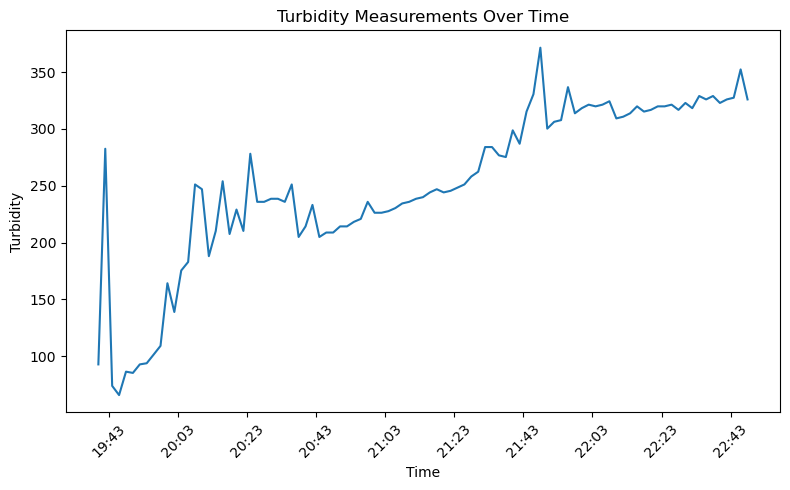

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data = pd.read_csv("last_data.csv")

data["DateTime"] = pd.to_datetime(data["Date"] + " " + data["Time"])

plt.figure(figsize=(8,5))
plt.plot(data["DateTime"], data["Turbidity"])
plt.xlabel("Time")
plt.ylabel("Turbidity")
plt.title("Turbidity Measurements Over Time")
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=20))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

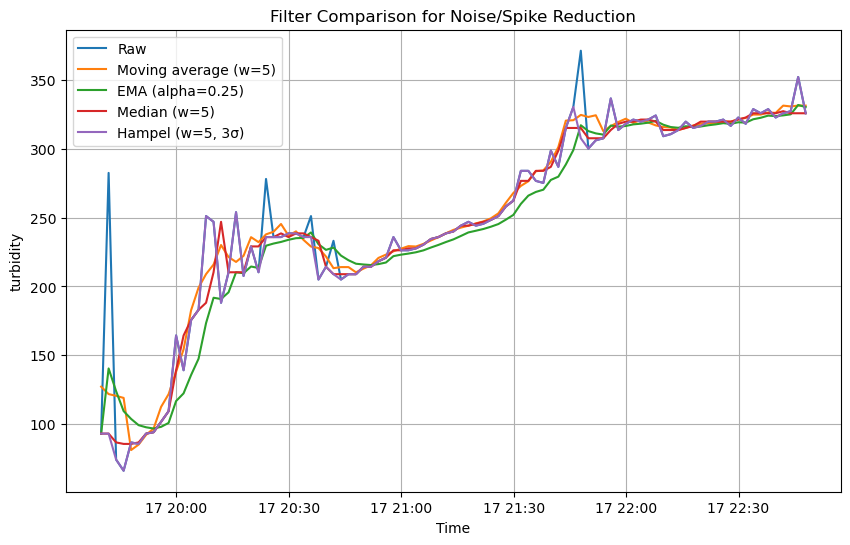

Max |Δ| between samples (°C)  (lower = fewer spikes)
Raw      : 208.60000000000002
MovAvg   : 37.94000000000001
EMA      : 47.42500000000001
Median   : 36.69999999999999
Hampel   : 68.19999999999999


In [31]:
time = data["DateTime"].to_numpy()
turbidity = data["Turbidity"].to_numpy()

# 1) Moving Average
def moving_average(x, window=5):
    if window < 1 or window % 2 == 0:
        raise ValueError("window must be an odd integer >= 1")
    kernel = np.ones(window) / window
    pad = window // 2
    xpad = np.pad(x, (pad, pad), mode="edge")
    return np.convolve(xpad, kernel, mode="valid")

# 2) Exponential Moving Average (EMA)
def ema(x, alpha=0.25):
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i-1]
    return out

# 3) Median Filter (great for spikes)
def median_filter_1d(x, window=5):
    if window < 1 or window % 2 == 0:
        raise ValueError("window must be an odd integer >= 1")
    pad = window // 2
    xpad = np.pad(x, (pad, pad), mode="edge")
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        out[i] = np.median(xpad[i:i+window])
    return out

# 4) Hampel Filter (outlier detection using MAD)
def hampel_filter(x, window=5, n_sigmas=3.0):
    if window < 1 or window % 2 == 0:
        raise ValueError("window must be an odd integer >= 1")
    pad = window // 2
    xpad = np.pad(x, (pad, pad), mode="edge")
    out = x.astype(float).copy()
    for i in range(len(x)):
        w = xpad[i:i+window]
        med = np.median(w)
        mad = np.median(np.abs(w - med))
        sigma = 1.4826 * mad if mad != 0 else 0.0
        if sigma > 0 and np.abs(x[i] - med) > n_sigmas * sigma:
            out[i] = med
    return out

# Apply filters
turbidity_ma   = moving_average(turbidity, window=5)
turbidity_ema  = ema(turbidity, alpha=0.25)
turbidity_med  = median_filter_1d(turbidity, window=5)
turbidity_hamp = hampel_filter(turbidity, window=7, n_sigmas=3.0)

# Plot comparison
plt.figure(figsize=(10,6))
plt.plot(time, turbidity, label="Raw")
plt.plot(time, turbidity_ma, label="Moving average (w=5)")
plt.plot(time, turbidity_ema, label="EMA (alpha=0.25)")
plt.plot(time, turbidity_med, label="Median (w=5)")
plt.plot(time, turbidity_hamp, label="Hampel (w=5, 3σ)")
plt.xlabel("Time")
plt.ylabel("turbidity")
plt.title("Filter Comparison for Noise/Spike Reduction")
plt.legend()
plt.grid(True)
plt.show()

# Simple metric: biggest step change (spike indicator)
def max_abs_diff(x):
    return float(np.max(np.abs(np.diff(x))))

print("Max |Δ| between samples (°C)  (lower = fewer spikes)")
print("Raw      :", max_abs_diff(turbidity))
print("MovAvg   :", max_abs_diff(turbidity_ma))
print("EMA      :", max_abs_diff(turbidity_ema))
print("Median   :", max_abs_diff(turbidity_med))
print("Hampel   :", max_abs_diff(turbidity_hamp))

In [10]:
def variance(x):
    return np.var(x)

print("\nVariance comparison (lower = smoother / less noise)")
print("Raw      :", variance(turbidity))
print("MovAvg   :", variance(turbidity_ma))
print("EMA      :", variance(turbidity_ema))
print("Median   :", variance(turbidity_med))
print("Hampel   :", variance(turbidity_hamp))

def std_dev(x):
    return np.std(x)

print("\nStandard deviation comparison")
print("Raw      :", std_dev(turbidity))
print("MovAvg   :", std_dev(turbidity_ma))
print("EMA      :", std_dev(turbidity_ema))
print("Median   :", std_dev(turbidity_med))
print("Hampel   :", std_dev(turbidity_hamp))

def smoothness(x):
    return np.mean(np.diff(x)**2)

print("\nSmoothness metric (lower = smoother)")
print("Raw      :", smoothness(turbidity))
print("MovAvg   :", smoothness(turbidity_ma))
print("EMA      :", smoothness(turbidity_ema))
print("Median   :", smoothness(turbidity_med))
print("Hampel   :", smoothness(turbidity_hamp))


Variance comparison (lower = smoother / less noise)
Raw      : 5022.882156232687
MovAvg   : 4564.558873085873
EMA      : 4794.171590388207
Median   : 4961.094275900276
Hampel   : 5155.821090304708

Standard deviation comparison
Raw      : 70.87229470133366
MovAvg   : 67.56151917390456
EMA      : 69.23995660302083
Median   : 70.43503585503649
Hampel   : 71.80404647584082

Smoothness metric (lower = smoother)
Raw      : 1294.0092553191491
MovAvg   : 59.52932765957452
EMA      : 64.06801499240947
Median   : 74.82691489361702
Hampel   : 298.5290425531914


C:\Users\ACER\AppData\Local\Temp\ipykernel_10232\788770047.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([turbidity, turbidity_ma, turbidity_ema, turbidity_med, turbidity_hamp],


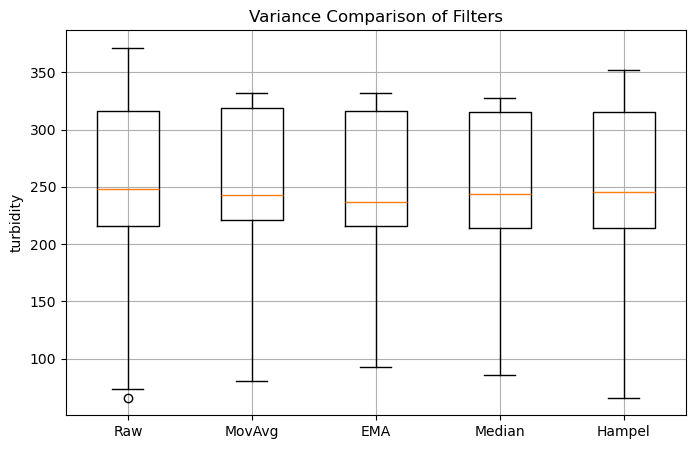

In [11]:
plt.figure(figsize=(8,5))
plt.boxplot([turbidity, turbidity_ma, turbidity_ema, turbidity_med, turbidity_hamp],
            labels=["Raw", "MovAvg", "EMA", "Median", "Hampel"])
plt.ylabel("turbidity")
plt.title("Variance Comparison of Filters")
plt.grid(True)
plt.show()

In [14]:
print("\nNoise reduction vs raw (%)")
for name, sig in [("MovAvg", turbidity_ma), ("EMA", turbidity_ema), ("Median", turbidity_med), ("Hampel", turbidity_hamp)]:
    reduction = 100*(variance(turbidity) - variance(sig))/variance(turbidity)
    print(name, ":", reduction)


Noise reduction vs raw (%)
MovAvg : 9.124707068392986
EMA : 4.553373117875806
Median : 1.2301280103842402
Hampel : -2.646666394652786


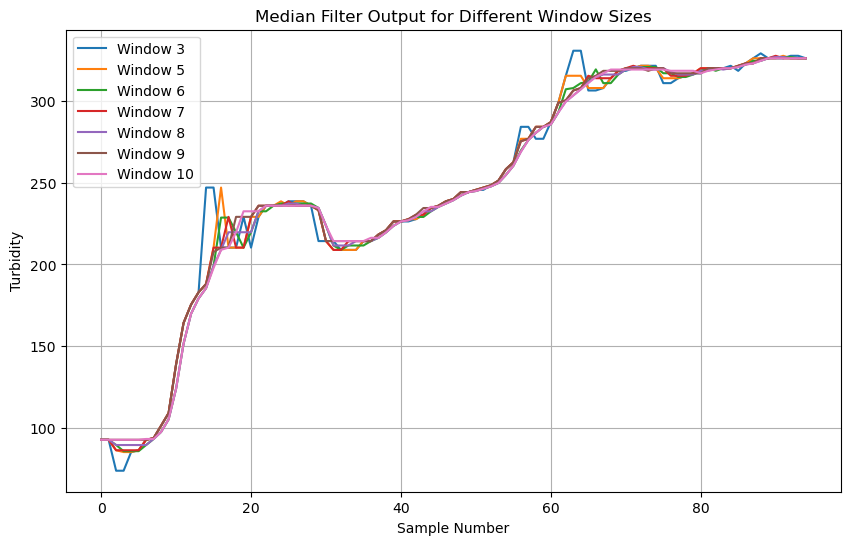


Median Filter Sensitivity:

Window  3 → Variance = 5051.6097 | Noise Energy = 11765.4300
Window  5 → Variance = 4961.0943 | Noise Energy = 7033.7300
Window  6 → Variance = 5024.5886 | Noise Energy = 4269.4450
Window  7 → Variance = 4936.7193 | Noise Energy = 4707.3300
Window  8 → Variance = 4977.6787 | Noise Energy = 3026.2050
Window  9 → Variance = 4842.0385 | Noise Energy = 3691.1500
Window 10 → Variance = 4923.3049 | Noise Energy = 2882.0150


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def noise_energy(x):
    return np.sum(np.diff(x)**2)
    
data = pd.read_csv("last_data.csv")
turbidity = data["Turbidity"].values

# Median filter
def median_filter_1d(x, window):
    pad = window // 2
    x_pad = np.pad(x, (pad, pad), mode='edge')
    y = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        y[i] = np.median(x_pad[i:i+window])
    return y

windows = [3, 5, 6, 7, 8, 9,10]

plt.figure(figsize=(10,6))

for w in windows:
    filtered = median_filter_1d(turbidity, w)
    plt.plot(filtered, label=f'Window {w}')

plt.title("Median Filter Output for Different Window Sizes")
plt.xlabel("Sample Number")
plt.ylabel("Turbidity")
plt.legend()
plt.grid(True)
plt.show()

print("\nMedian Filter Sensitivity:\n")

for w in windows:
    filtered = median_filter_1d(turbidity, w)
    variance = np.var(filtered)
    energy = noise_energy(filtered)
    print(f"Window {w:2d} → Variance = {variance:.4f} | Noise Energy = {energy:.4f}")

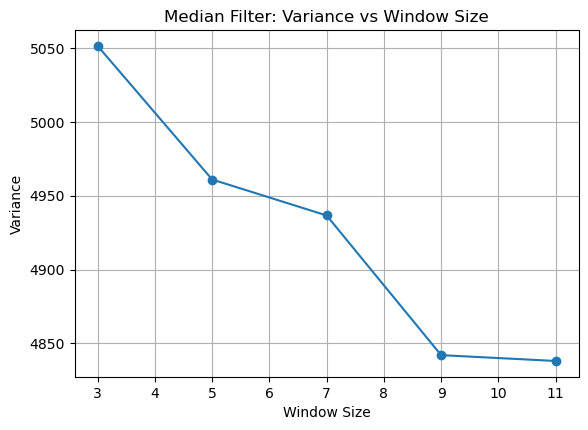

In [22]:
windows = [3, 5, 7, 9, 11]

vars_by_w = []
energy_by_w = []

for w in windows:
    filtered = median_filter_1d(turbidity, w)
    vars_by_w.append(np.var(filtered))
    energy_by_w.append(noise_energy(filtered))

plt.figure(figsize=(6.5,4.5))
plt.plot(windows, vars_by_w, marker='o')
plt.title("Median Filter: Variance vs Window Size")
plt.xlabel("Window Size")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

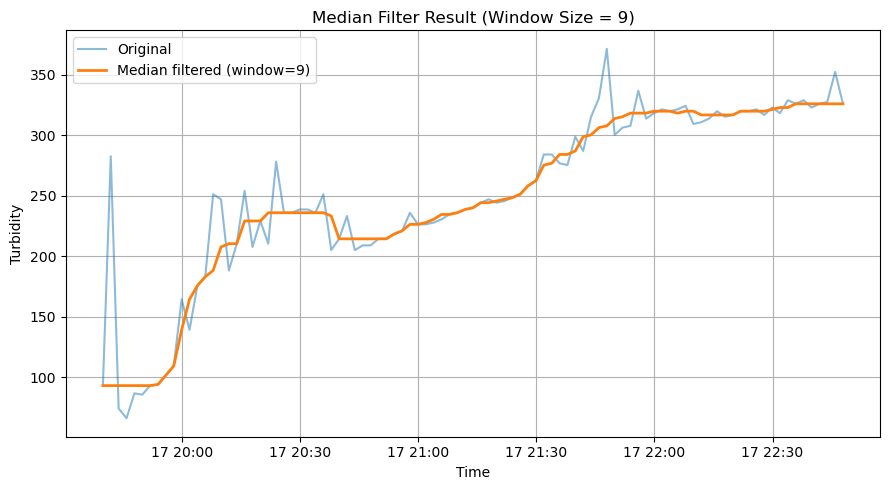

In [29]:
# Force window size to 9
window_size = 9

best_filtered = median_filter_1d(turbidity, window_size)

# Make sure DateTime exists
data["DateTime"] = pd.to_datetime(data["Date"] + " " + data["Time"])

plt.figure(figsize=(9,5))
plt.plot(data["DateTime"], data["Turbidity"], label="Original", alpha=0.5)
plt.plot(data["DateTime"], best_filtered,
         linewidth=2,
         label="Median filtered (window=9)")

plt.title("Median Filter Result (Window Size = 9)")
plt.xlabel("Time")
plt.ylabel("Turbidity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
improvement = (np.var(turbidity) - np.var(best_filtered)) / np.var(turbidity) * 100
print("Noise reduction % =", improvement)
rmse = np.sqrt(np.mean((turbidity - best_filtered)**2))
print("RMSE:", rmse)
changes = np.diff(best_filtered)
spikes = np.where(np.abs(changes) > 20)[0]
print("Sudden turbidity events at samples:", spikes)

Noise reduction % = 3.6003960764470806
RMSE: 24.456756681302224
Sudden turbidity events at samples: [ 9 10]
